## Resolution Time Summary

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

df = pd.read_csv("../data/processed/itsm_incident_clean.csv")
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
df.head()

,status,ticket_id,priority,source,topic,agent_group,agent_name,created_time,expected_sla_to_resolve,expected_sla_to_first_response,...,survey_results,product_group,support_level,country,latitude,longitude,created_hour,created_day_of_week,created_month,resolution_duration_hours
0,Closed,TCKT-100000,High,Email,General Inquiry,Security,Khalid Al-Salem,2024-07-04 12:42:00,2024-07-04 14:42:00,2024-07-04 13:12:00,...,Neutral,Cloud,L3,Oman,25.1856,50.9447,12.0,Thursday,7.0,1.800000
1,Closed,TCKT-100001,High,Chat,Network Issue,Customer Service,Ahmed Al-Sabah,2024-05-23 20:03:00,2024-05-23 22:03:00,2024-05-23 20:33:00,...,Dissatisfied,Cloud,L2,Qatar,23.2741,55.3867,20.0,Thursday,5.0,1.950000
2,In Progress,TCKT-100002,Low,Phone,General Inquiry,Development,Mohammed Al-Mansoori,2024-04-13 20:51:00,NaN,2024-04-13 21:51:00,...,Dissatisfied,Software,L1,Bahrain,23.6264,50.1302,20.0,Saturday,4.0,NaN
3,Resolved,TCKT-100003,Critical,Chat,Access Request,Development,Mohammed Al-Khalifa,2024-05-13 12:50:00,2024-05-13 13:50:00,2024-05-13 13:00:00,...,Dissatisfied,Network,L2,Kuwait,25.0736,54.8437,12.0,Monday,5.0,0.966667
4,Closed,TCKT-100004,Critical,Portal,Hardware Failure,Customer Service,Hassan Al-Nasser,2024-06-19 22:51:00,2024-06-19 23:51:00,2024-06-19 23:01:00,...,Neutral,Hardware,L3,Qatar,24.7362,51.4839,22.0,Wednesday,6.0,0.966667


In [16]:
resolution_summary = df["resolution_duration_hours"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

print(resolution_summary)

mean      2.223044
median    1.950000
std       1.119226
min       0.666667
max       4.000000
Name: resolution_duration_hours, dtype: float64


## Agent Group Performance 


In [23]:
df_anova = df.dropna(subset=["resolution_duration_hours"])

grouped_data = [
    group["resolution_duration_hours"].values
    for name, group in df_anova.groupby("agent_group")
    if len(group) > 1
]

f_stat, p_value = f_oneway(*grouped_data)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 2.2416551636345146
p-value: 0.06195552285830521


## Topic Resolution Differences

In [25]:
df_anova = df.dropna(subset=["resolution_duration_hours"])

valid_topics = df_anova.groupby("topic").filter(lambda x: len(x) > 1)
topic_groups = [
    group["resolution_duration_hours"].values
    for name, group in valid_topics.groupby("topic")
]
f_stat, p_value = f_oneway(*topic_groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.1688253900441352
p-value: 0.3222787257771982


## Hourly Demand Variability

In [26]:
hourly_ticket_counts = df.groupby("created_hour").size()
print(hourly_ticket_counts)
hourly_variance = hourly_ticket_counts.var()
print("Hourly demand variance:", hourly_variance)

created_hour
10.0    4211
11.0    4214
12.0    4173
13.0    4119
14.0    4178
15.0    4135
16.0    4073
17.0    4188
18.0    4211
19.0    4169
20.0    4168
21.0    4137
22.0    4201
23.0    4198
dtype: int64
Hourly demand variance: 1674.401098901098


## Correlation between resolution time and agent interactions


                           resolution_duration_hours  agent_interactions
resolution_duration_hours                   1.000000            0.004949
agent_interactions                          0.004949            1.000000


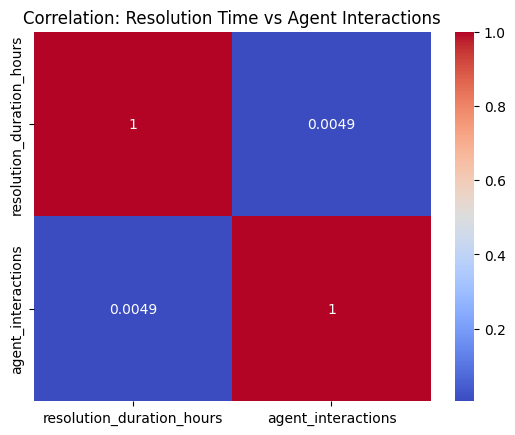

In [ ]:
correlation_matrix = df[["resolution_duration_hours", "agent_interactions"]].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation: Resolution Time vs Agent Interactions")
plt.show()

## SLA Breach Rate KPI

In [ ]:
df["sla_breach"] = df["sla_for_resolution"] == "Breached"
sla_breach_rate = df["sla_breach"].mean()
print("SLA Breach Rate:", sla_breach_rate)
sla_breach_by_group = df.groupby("agent_group")["sla_breach"].mean()
print(sla_breach_by_group)

SLA Breach Rate: 0.0
agent_group
Customer Service    0.0
Development         0.0
IT Support          0.0
Network Ops         0.0
Security            0.0
Name: sla_breach, dtype: float64


## Resolution Time Distribution

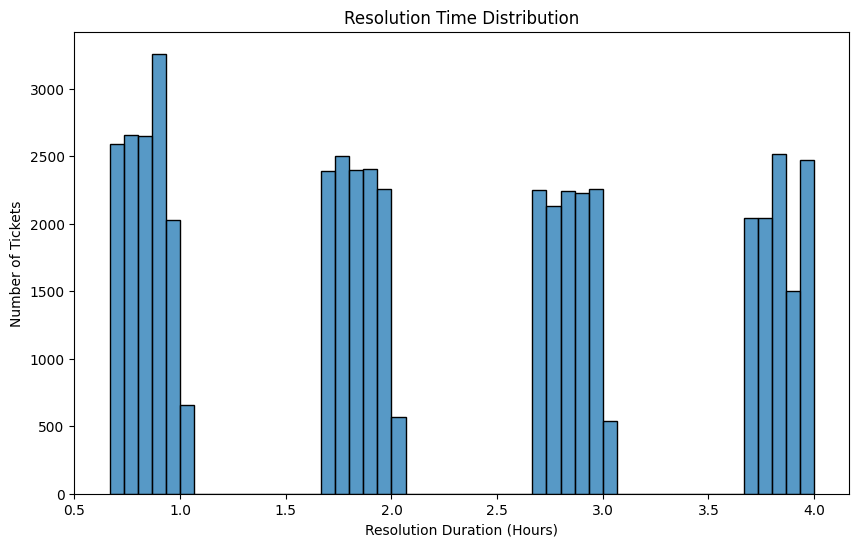

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df["resolution_duration_hours"], bins=50)

plt.title("Resolution Time Distribution")
plt.xlabel("Resolution Duration (Hours)")
plt.ylabel("Number of Tickets")

plt.show()